In [1]:
import numpy as np
import os

# run once
os.chdir("..")

In [2]:
from dirdet.plotting import plot_neutrino_groups
from dirdet.config.physics import NeutrinoRegistry
from dirdet.helpers import dRdE_neutrino_dict
from dirdet.plotting import plot_neutrino_groups

# Neutrino Flux Plots

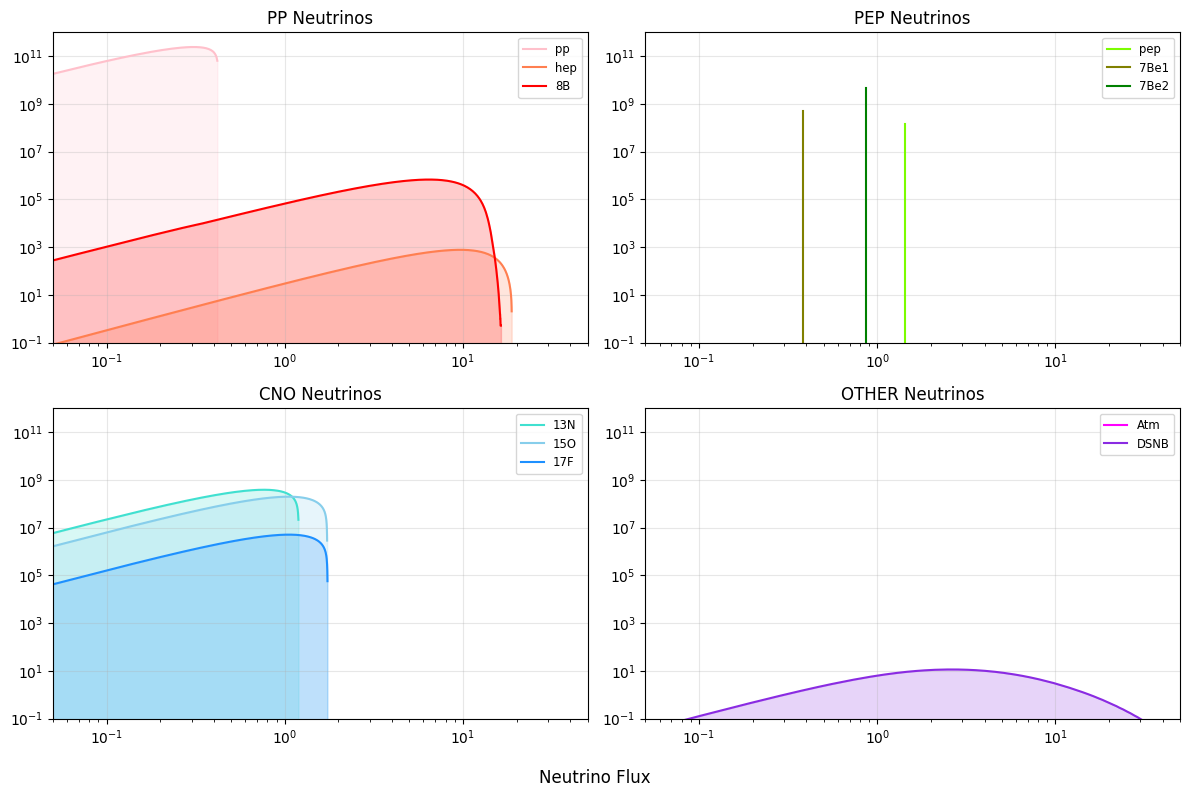

In [3]:
# define location of flux and energy
dir = "input_data/neutrino_fluxes"

nu_energy, nu_flux = {}, {}

all_nu_sources = NeutrinoRegistry.all_sources()

for source in all_nu_sources:
    path = f"{dir}/{source.name}.txt"
    nu_energy[source.name], nu_flux[source.name] = np.loadtxt(path, unpack=True)

# plotting
plot_neutrino_groups(
    y_data_dict=nu_flux,
    x_data=nu_energy, 
    sup_xaxis="Neutrino Energy $E_{\\nu}$ [MeV]",
    sup_yaxis="Flux $\\Phi$ [cm$^{-2}$s$^{-1}$MeV$^{-1}$]",
    sup_title="Neutrino Flux"
)

# Neutrino Recoil Rates

## Theory

We will now plot the expected nuclear recoil rate induced by these neutrinos, as a function of the nuclear recoil energy. This recoil is a very well understood standard model process called Coherent Elastic Neutrino-Nucleus Scattering **CE**$\nu$**NS**, and the differential cross section as a function of recoil energy $E_r$ and neutrino energy $E_{\nu}$ is given as
$$
\frac{d\sigma}{dE_{r}}(E_{r}E_{\nu})= \frac{G^{2}_{F}Q^{2}_{W}m_{N}}{4\pi}\times\left( 1-\frac{m_{N}E_{r}}{2E_{\nu}^{2}} \right) \times F^{2}(E_{r})\text{.}
$$

$Q_{W}=A-Z-(1-4\sin ^{2}\theta_{W})Z$ is weak nuclear hypercharge of a nucleus with mass $m_N$, $F^2(E_r)$ is the Helm ansatz form factor, required for encoding the loss of coherence at higher energy recoil, $G_F$ and $\theta_W$ are the Fermi coupling constant and weak mixing angle respectively.

The $\text{CE}\nu\text{NS}$ event rate per unit mass as a function of the recoil energy is then given through the convolution of the differential cross-section $d\sigma/dE_r$ and the neutrino flux $d\Phi/dE_r$
$$
\frac{dR}{dE_{r}}=\frac{1}{m_{N}}\int_{E_{\nu}^{\text{min}}} \frac{d\sigma}{dE_{r}} \times \frac{d\Phi}{dE_{\nu}}dE_{\nu}\text{,}
$$
where $E_{\nu}^{\text{min}}$ is the minimum neutrino energy required to generate a nuclear recoil $E_r$.

## Plot

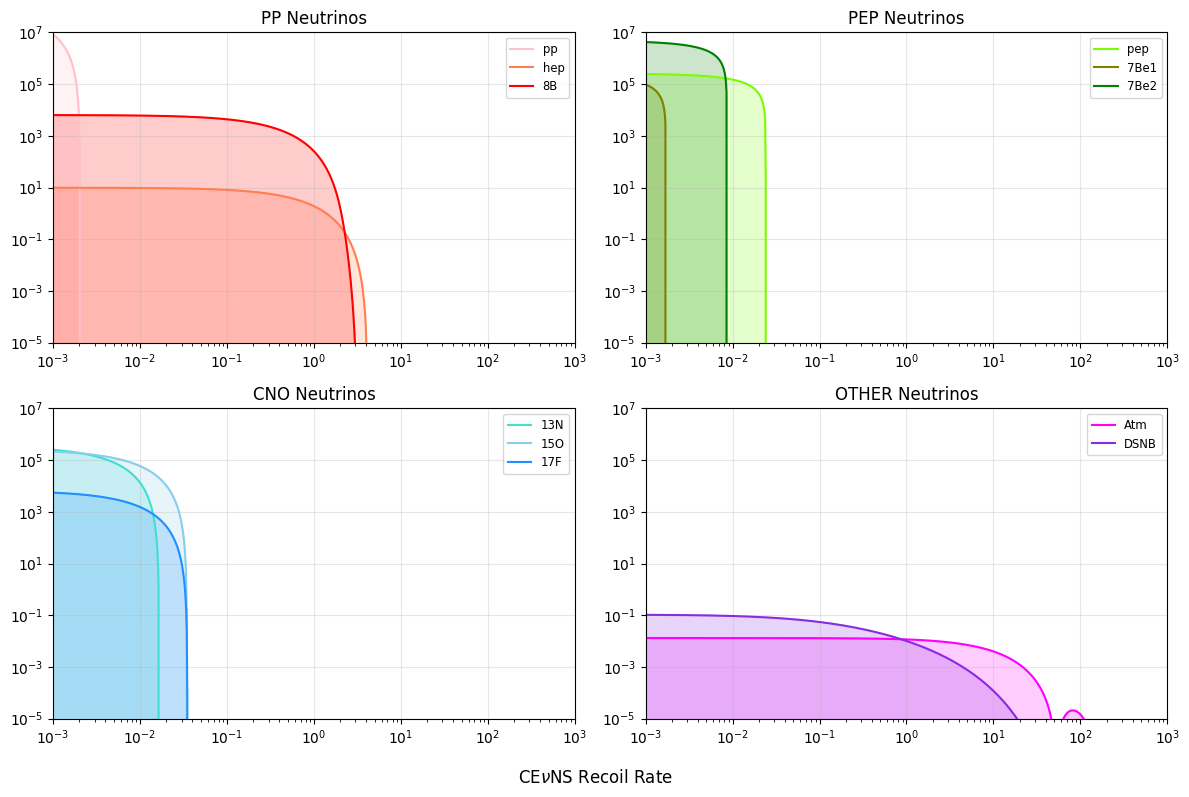

In [ ]:


# calculate values
E_r = np.geomspace(1e-3,1e3,1000)
dR_nu_dict = dRdE_neutrino_dict()

# plot
plot_neutrino_groups(
    x_data=E_r, 
    y_data_dict=dR_nu_dict, 
    sup_xaxis="Nucelar Recoil Energy $E_{r}$ [keV]",
    sup_yaxis="Recoil Rate [ton$^{-1}$year$^{-1}$keV$^{-1}$]",
    sup_title="CE$\\nu$NS Recoil Rate",
    xlim=(1e-3,1e3),
    ylim=(1e-5,1e7),
)